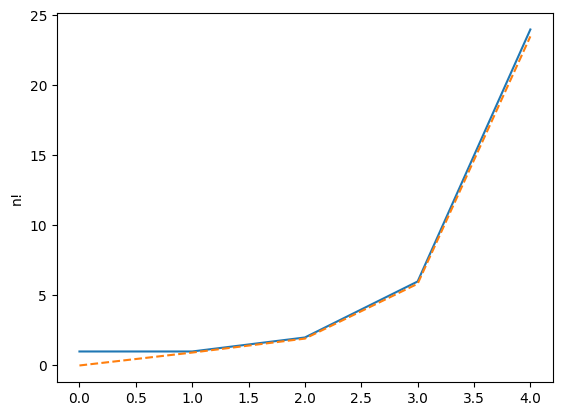

[ 1.  1.  2.  6. 24.]
[ 0.          0.92213701  1.91900435  5.83620959 23.50617513]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
#import scipy 
from sympy import Sum, simplify, symbols, factorial, sqrt, pi, exp, N, lambdify 


n_values = np.arange(0, 5)
n, k = symbols('n k')
exact_exrp = sp.factorial(n)
aprox_exrp = sqrt(2 * pi * n) * (n / exp(1))**n


na_exact = lambdify(n, exact_exrp, modules=['numpy', 'scipy'])
na_aprox = lambdify(n, aprox_exrp, modules=['numpy', 'scipy'])
exact_val = na_exact(n_values)
aprox_val = na_aprox(n_values)

   


plt.plot(n_values, exact_val)
plt.plot(n_values, aprox_val, linestyle="--")

plt.ylabel('n!')

plt.show()
print(exact_val)
print(aprox_val)


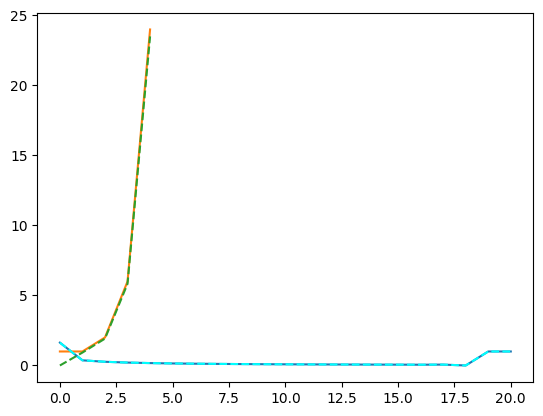

[1.63212056 0.36787944 0.26424112 0.20727665 0.17089341 0.14553294
 0.12680236 0.1123835  0.10093197 0.09161229 0.08387707 0.07735223
 0.07177323 0.06694794 0.06272888 0.05908203 0.0546875  0.0625
 0.         1.         1.        ]


In [2]:
from sympy import Sum 

new_n_values = np.arange(0, 21)

#with aprox_exrp

factorial_expr = sp.factorial(n-k)
In = 1 + Sum((-1)**k*(aprox_exrp/factorial_expr), (k, 1, n - 1)) + ((-1)**n)*aprox_exrp*(1-exp(-1))

#with exact_exrp

factorial_expr = sp.factorial(n-k)
In = 1 + Sum((-1)**k*(exact_exrp/factorial_expr), (k, 1, n - 1)) + ((-1)**n)*exact_exrp*(1-exp(-1))

exact_na_integral = lambdify(n, In.doit(), modules=['numpy', 'scipy']) #alt
na_integral = lambdify(n, In.doit(), modules=['numpy', 'scipy'])

exact_integral = np.vectorize(exact_na_integral)
integral = np.vectorize(na_integral)

integral_val = integral(new_n_values)
exact_integral_val = exact_integral(new_n_values) #values

plt.plot(new_n_values, exact_integral_val)
plt.plot(n_values, exact_val)
plt.plot(n_values, aprox_val, linestyle="--")
plt.plot(new_n_values, integral_val, linestyle="--", color="cyan")


plt.show()

print(integral_val)